# Temas Tratados en el Trabajo Práctico 8

* Aprendizaje estadístico.

* Evolución de la verosimilitud de una hipótesis en función de observaciones.

* Aprendizaje no supervisado. Algoritmo K-means.

* Aprendizaje supervisado. Algoritmo Knn.

* Aprendizaje por refuerzo. Algoritmo Q-Learning.

## Ejercicios Teóricos

1. Un fabricante de tornillos vende cajas que contienen 1000 tornillos de cabeza redonda con tres tipos de recubrimiento electrolítico (cincado, cobre y níquel). Cada caja se rellena
con diferentes proporciones que pueden variar de la siguiente manera:

&emsp;&emsp;a: Todos los tornillos están recubiertos de níquel. 15 de cada 100 cajas se llenan de esta manera.

&emsp;&emsp;b: El 70% de los tornillos están recubiertos de níquel, el 20% de cobre, el resto está cincado. 15 de cada 100 cajas se llenan de esta manera.

&emsp;&emsp;c: El 50% de los tornillos están recubiertos de níquel, el 25% de cobre y el resto está cincado. 50 de cada 100 cajas se llenan de esta manera.

&emsp;&emsp;d: El 20 % de los tornillos están recubiertos de níquel, el 50% de cobre y el resto está cincado. 10 de cada 100 cajas se llenan de esta manera.

&emsp;&emsp;e: Todos los tornillos están recubiertos de cobre. 10 de cada 100 cajas se llenan de esta manera.

&emsp;&emsp;1.1 ¿Cuál es la distribución a priori sobre las hipótesis?

Definimos la variable aleatoria de hipótesis $H = {h_a, h_b, h_c, h_d, h_e}$ según la composición de la caja. La probabilidad a priori $P(h_i)$ corresponde a la proporción de cajas que se rellenan con cada combinación:

$h_a$ (100% Níquel, 0% Cobre): $P(h_a) = \frac{15}{100} = \mathbf{0.15}$

$h_b$ (70% Níquel, 20% Cobre, 10% Cincado): $P(h_b) = \frac{15}{100} = \mathbf{0.15}$

$h_c$ (50% Níquel, 25% Cobre, 25% Cincado): $P(h_c) = \frac{50}{100} = \mathbf{0.50}$

$h_d$ (20% Níquel, 50% Cobre, 30% Cincado): $P(h_d) = \frac{10}{100} = \mathbf{0.10}$

$h_e$ (100% Cobre): $P(h_e) = \frac{10}{100} = \mathbf{0.10}$

$$
\mathbf{P(H)} = \langle 0.15,  0.15,  0.50,  0.10,  0.10 \rangle
$$

&emsp;Considerando que los 10 primeros tornillos que se extraen de una caja de muestra son de cobre:

&emsp;&emsp;1.2 Calcule la probabilidad de cada hipótesis dado que los 10 primeros tornillos fueron de cobre.

| $h_i$ | $P(\text{cobre} \mid h_i)$ | $P \text{ priori } P(h_i)$ | $P(h_i \mid d_1)$ | $P(h_i \mid d_2)$ | $P(h_i \mid d_3)$ | $P(h_i \mid d_4)$ | $P(h_i \mid d_5)$ | $P(h_i \mid d_6)$ | $P(h_i \mid d_7)$ | $P(h_i \mid d_8)$ | $P(h_i \mid d_9)$ | $P(h_i \mid d_{10})$ |
|:-----:|--------------------------:|---------------------------:|------------------:|------------------:|------------------:|------------------:|------------------:|------------------:|------------------:|------------------:|------------------:|---------------------:|
| **a** | 0.000 | 0.150 | 0.000 | 0.000 | 0.000 | 0.000 | 0.000 | 0.000 | 0.000 | 0.000 | 0.000 | 0.000 |
| **b** | 0.200 | 0.150 | 0.098 | 0.037 | 0.010 | 0.002 | 0.000 | 0.000 | 0.000 | 0.000 | 0.000 | 0.000 |
| **c** | 0.250 | 0.500 | 0.410 | 0.193 | 0.064 | 0.018 | 0.005 | 0.001 | 0.000 | 0.000 | 0.000 | 0.000 |
| **d** | 0.500 | 0.100 | 0.164 | 0.154 | 0.103 | 0.058 | 0.030 | 0.015 | 0.008 | 0.004 | 0.002 | 0.001 |
| **e** | 1.000 | 0.100 | 0.328 | 0.616 | 0.823 | 0.922 | 0.965 | 0.983 | 0.992 | 0.996 | 0.998 | **0.999** |
| | **$P(D)$** | | **0.305** | **0.532** | **0.749** | **0.892** | **0.956** | **0.981** | **0.991** | **0.996** | **0.998** | **0.999** |
| | **alfa** | | **3.279** | **1.880** | **1.335** | **1.121** | **1.046** | **1.019** | **1.009** | **1.004** | **1.002** | **1.001** |


&emsp;&emsp;1.3 Grafique la evolución de la verosimilitud de cada hipótesis en función del número de tornillos extraídos de la caja.

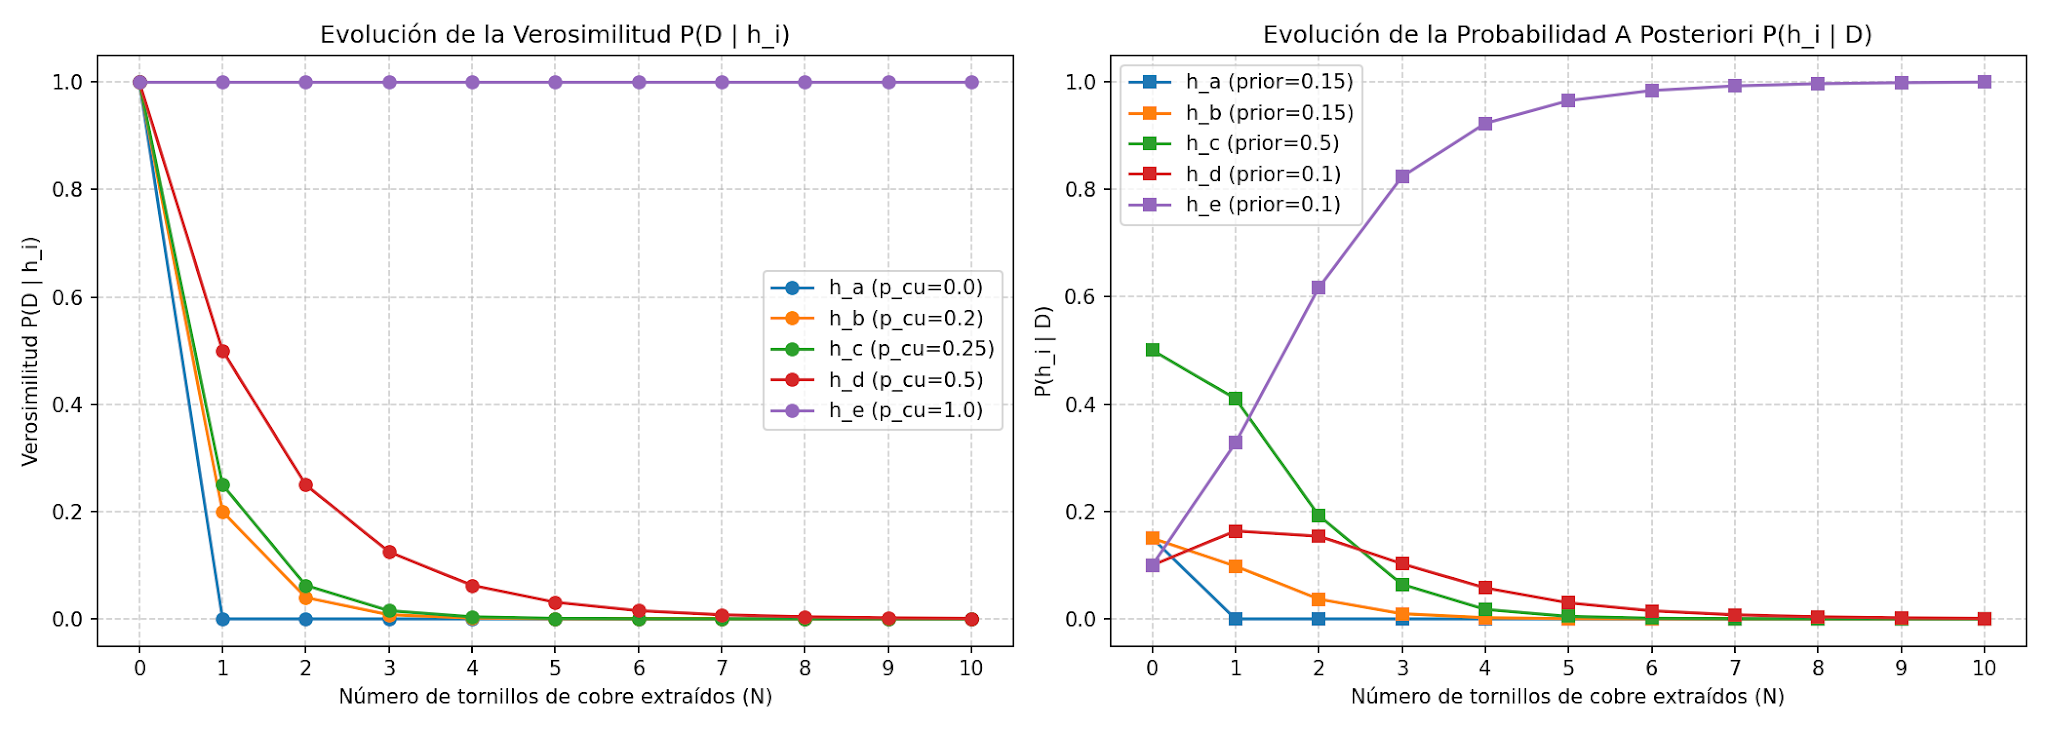
Comportamiento de la Verosimilitud $P(D \mid h_i)$: Para la hipótesis $h_e$, la verosimilitud se mantiene constante en $1.0$. Para las demás hipótesis, decae exponencialmente conforme aumenta el número $N$ de extracciones de cobre.

Comportamiento de la Probabilidad A Posteriori $P(h_i \mid D)$: Comienza en la distribución a priori ($N=0$). Con $N=1$ y $N=2$, las hipótesis $h_c$ y $h_d$ retienen cierta probabilidad, pero a partir de $N \ge 3$, la hipótesis $h_e$ domina completamente la probabilidad acumulada.

&emsp;&emsp;1.4 Para cada hipótesis, ¿cuál es la probabilidad de que el cuarto tornillo extraído sea de cobre?

Si con "el cuarto tornillo" se refieren al evento de sacar 4 tornillos de cobre de forma consecutiva ($P(\text{Cu})^4$) para cada caja $h_i$:

**$h_a$:** $0^4 = \mathbf{0} \quad (0\%)$

**$h_b$:** $0.20^4 = 0.0016 \quad (\mathbf{0.16\%})$

**$h_c$:** $0.25^4 = 0.00390625 \quad (\mathbf{0.39\%})$

**$h_d$:** $0.50^4 = 0.0625 \quad (\mathbf{6.25\%})$

**$h_e$:** $1.00^4 = 1.00 \quad (\mathbf{100\%})$


2. ¿Qué diferencia principal existe entre un algoritmo supervisado y un algoritmo no supervisado?

## Ejercicios de implementación

> Recuerde adjuntar en la presentación el prompt inicial que ha utilizado para cada ejercicio de implementación y si considera que le dio la información completa para resolver el ejercicio o qué cambios adicionales tuvo que pedir de manera iterativa.

3. Genere un conjunto de 23 puntos que contengan coordenadas *xy* aleatorias con valores contenidos en el intervalo [0, 5] y grafique los puntos obtenidos en un gráfico.

&emsp;&emsp;3.1 Implemente un algoritmo K-means que clasifique 20 de los puntos en 2 grupos y grafique el resultado asignando un color a cada uno.


&emsp;&emsp;3.2 Tome los tres puntos restantes y clasifíquelos en los grupos obtenidos anteriormente usando el algoritmo Knn. Utilice distintos valores de K y anote lo que observa con esta elección.

4. La imagen mostrada abajo muestra una red de salas y cómo se comunican entre ellas. Implemente un algoritmo Q-Learning con un factor despreciativo $γ = 0.9$. La matriz de recompensas debe asignar un valor de 0 a cada camino accesible y un valor de 100 a caminos que lleven a la sala del tesoro.

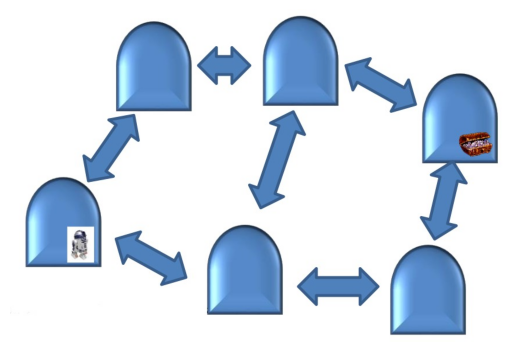

In [1]:
import requests
from PIL import Image
from io import BytesIO
import matplotlib.pyplot as plt

# URL directa de Google Drive
url = "https://drive.google.com/uc?export=view&id=1dkDruEIPa7f-BAmjI47TZl3bxaqYf6a9"

# Descargar la imagen
response = requests.get(url)
img = Image.open(BytesIO(response.content))

# Mostrar la imagen
plt.imshow(img)
plt.axis('off')  # Ocultar ejes
plt.show()

&emsp;&emsp;4.1 Dibuje un diagrama con la asignación de recompensas correspondiente a cada estado.

&emsp;&emsp;4.2 Diseñe y muestre la matriz de recompensas.

&emsp;&emsp;4.3 Obtenga la matriz Q óptima, normalícela respecto al valor máximo encontrado y grafique la política obtenida en el diagrama mostrado inicialmente.

# Bibliografía

[Russell, S. & Norvig, P. (2004) _Inteligencia Artificial: Un Enfoque Moderno_. Pearson Educación S.A. (2a Ed.) Madrid, España](https://www.academia.edu/8241613/Inteligencia_Aritificial_Un_Enfoque_Moderno_2da_Edici%C3%B3n_Stuart_J_Russell_y_Peter_Norvig)

[Poole, D. & Mackworth, A. (2017) _Artificial Intelligence: Foundations of Computational Agents_. Cambridge University Press (3a Ed.) Vancouver, Canada](https://artint.info/3e/html/ArtInt3e.html)